# Task 2: Exploratory Data Analysis (EDA) - House Prices



## Introduction

In this notebook, we will perform an **Exploratory Data Analysis** to understand the factors that influence house sale prices in Ames, Iowa.



**Our workflow will consist of:**

1. **Data Loading:** Importing the full dataset and setting the environment.

2. **Correlation Analysis:** Identifying the top 10 numerical variables most correlated with `SalePrice` using Spearman's method.

3. **Deep Dive Analysis:** We will focus our detailed investigation on the following key variables:

    * `OverallQual` (Overall Quality)

    * `GrLivArea` (Above ground living area)

    * `YearBuilt` (Original construction date)

    * `KitchenQual` (Kitchen quality)



In [1]:
import pandas as pd
import os

# Set the absolute path to the project root
full_project_path = "/workspaces/heritage-housing-issues"
os.chdir(full_project_path)

# Define the file path
file_path = "inputs/datasets/raw/house-price/house_prices_records.csv"

# Load the dataset
df = pd.read_csv(file_path)

# Display data shape and the first few rows
print(f"Dataset loaded successfully with {df.shape[0]} rows and {df.shape[1]} columns.")
df.head()

Dataset loaded successfully with 1460 rows and 24 columns.


,1stFlrSF,2ndFlrSF,BedroomAbvGr,BsmtExposure,BsmtFinSF1,BsmtFinType1,BsmtUnfSF,EnclosedPorch,GarageArea,GarageFinish,...,LotFrontage,MasVnrArea,OpenPorchSF,OverallCond,OverallQual,TotalBsmtSF,WoodDeckSF,YearBuilt,YearRemodAdd,SalePrice
0,856,854.0,3.0,No,706,GLQ,150,0.0,548,RFn,...,65.0,196.0,61,5,7,856,0.0,2003,2003,208500
1,1262,0.0,3.0,Gd,978,ALQ,284,NaN,460,RFn,...,80.0,0.0,0,8,6,1262,NaN,1976,1976,181500
2,920,866.0,3.0,Mn,486,GLQ,434,0.0,608,RFn,...,68.0,162.0,42,5,7,920,NaN,2001,2002,223500
3,961,NaN,NaN,No,216,ALQ,540,NaN,642,Unf,...,60.0,0.0,35,5,7,756,NaN,1915,1970,140000
4,1145,NaN,4.0,Av,655,GLQ,490,0.0,836,RFn,...,84.0,350.0,84,5,8,1145,NaN,2000,2000,250000


Top 10 numerical features with strongest correlation to SalePrice:
SalePrice       1.000000
OverallQual     0.809829
GrLivArea       0.731310
YearBuilt       0.652682
GarageArea      0.649379
TotalBsmtSF     0.602725
GarageYrBlt     0.593788
1stFlrSF        0.575408
YearRemodAdd    0.571159
OpenPorchSF     0.477561
LotArea         0.456461
Name: SalePrice, dtype: float64


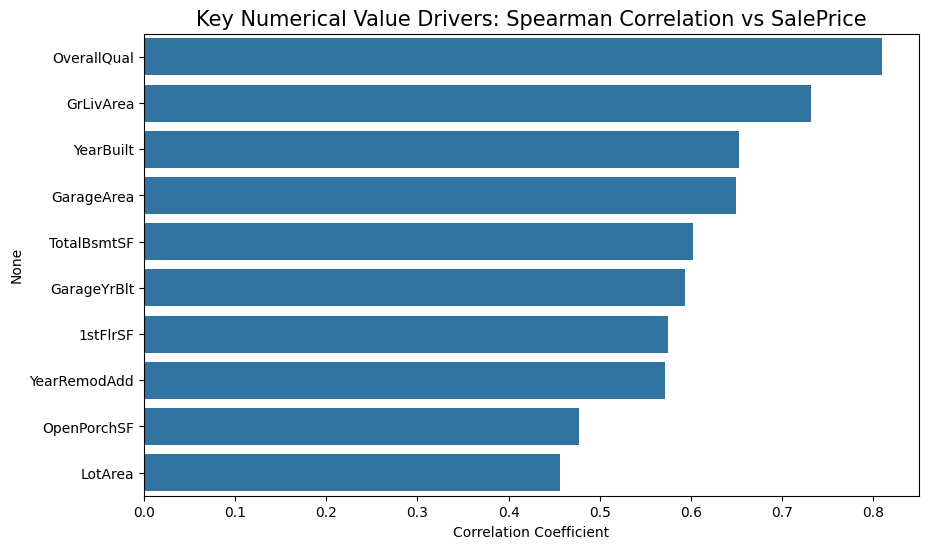

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Filter only numerical columns to avoid text-to-float errors
df_numerical = df.select_dtypes(include=['int64', 'float64'])

# Step 2: Calculate Spearman correlation only on numerical data
corr_spearman = df_numerical.corr(method='spearman')['SalePrice'].sort_values(ascending=False)

# Step 3: Display results
print("Top 10 numerical features with strongest correlation to SalePrice:")
print(corr_spearman.head(11))

# Step 4: Professional Visualization
plt.figure(figsize=(10, 6))
sns.barplot(x=corr_spearman.head(11).drop('SalePrice').values, 
            y=corr_spearman.head(11).drop('SalePrice').index)
plt.title("Key Numerical Value Drivers: Spearman Correlation vs SalePrice", fontsize=15)
plt.xlabel("Correlation Coefficient")
plt.show()

### Finding: 
There is a **strong positive correlation** between `GrLivArea` (Above ground living area square feet) and `SalePrice`. 

* The scatter plot shows that as the square footage increases, the house price typically rises. 
* This confirms the hypothesis that larger living spaces significantly drive up property value.

---
## 1 - Analysis of the first correlational variable: `OverallQual`
We will now visualize the relationship between the house's overall quality rating and its final sale price to validate if higher quality consistently leads to higher value.

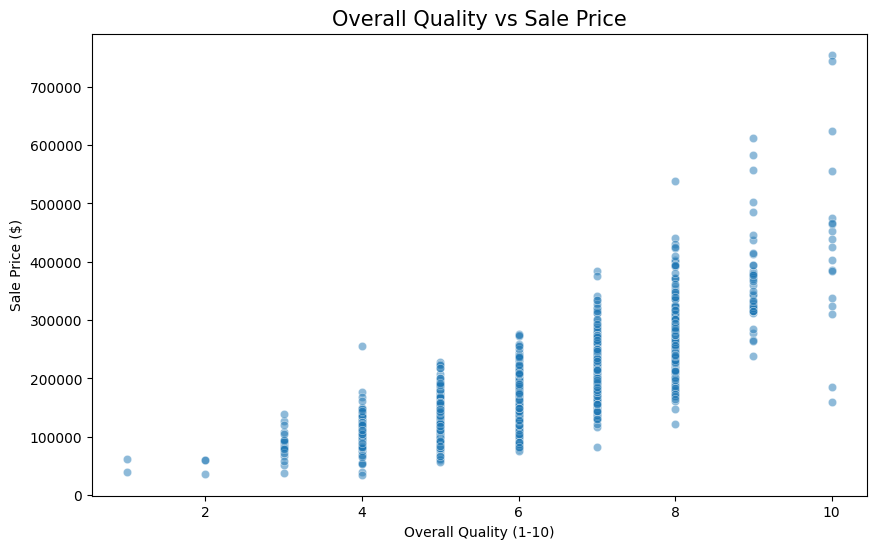

In [4]:
# Investigating the top correlated variable: OverallQual vs SalePrice
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='OverallQual', y='SalePrice', alpha=0.5)
plt.title("Overall Quality vs Sale Price", fontsize=15)
plt.xlabel("Overall Quality (1-10)")
plt.ylabel("Sale Price ($)")
plt.show()

### Finding: 
The scatter plot reveals a **strong positive correlation** between `OverallQual` and `SalePrice`. 

* As the quality rating increases from 1 to 10, the sale price tends to rise significantly. 
* This confirms our hypothesis that house quality is a primary driver of market value.

---
## 2 - Analysis of the second correlational variable: `GrLivArea`
In this section, we investigate how the size of the living area above ground affects the market price.

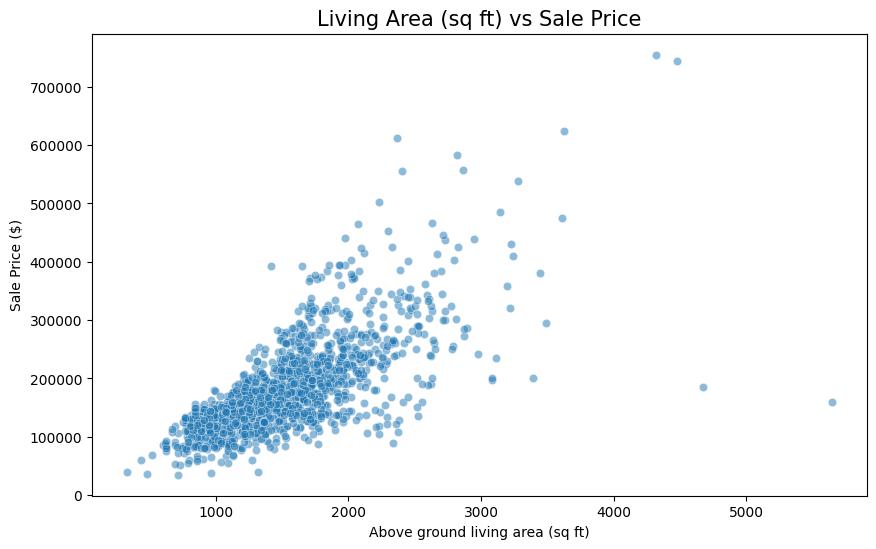

In [5]:
# Investigating the second strongest correlation: GrLivArea vs SalePrice
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='GrLivArea', y='SalePrice', alpha=0.5)
plt.title("Living Area (sq ft) vs Sale Price", fontsize=15)
plt.xlabel("Above ground living area (sq ft)")
plt.ylabel("Sale Price ($)")
plt.show()

### Finding: 
There is a **strong positive correlation** between `GrLivArea` (Above ground living area square feet) and `SalePrice`. 

* The scatter plot shows that as the square footage increases, the house price typically rises. 
* This confirms the hypothesis that larger living spaces significantly drive up property value.

---
## 3 - Analysis of the third variable: `KitchenQual` (Categorical)
Since kitchen quality is a categorical variable, we will use a **Box Plot** to visualize its impact on the `SalePrice`. This helps us understand how the market values different levels of interior finishing.

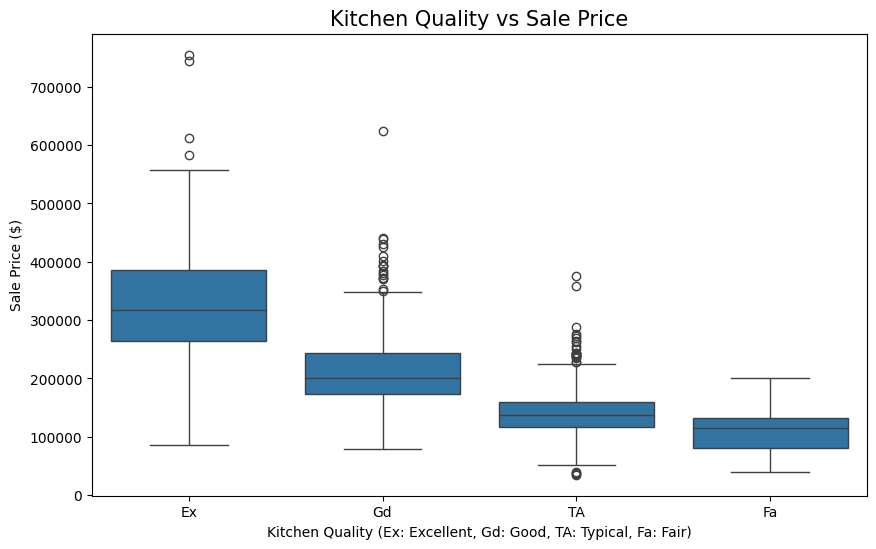

In [7]:
# Boxplot for Kitchen Quality vs Sale Price
plt.figure(figsize=(10, 6))
# We define the order from Excellent to Fair for better visualization
sns.boxplot(data=df, x='KitchenQual', y='SalePrice', order=['Ex', 'Gd', 'TA', 'Fa'])
plt.title("Kitchen Quality vs Sale Price", fontsize=15)
plt.xlabel("Kitchen Quality (Ex: Excellent, Gd: Good, TA: Typical, Fa: Fair)")
plt.ylabel("Sale Price ($)")
plt.show()

### Finding: 
The box plot reveals that **Kitchen Quality** is a significant driver of property value.

* Houses with **Excellent (Ex)** kitchens have a much higher median price compared to other categories.
* There is a clear "stepped" decrease in price as quality moves down to **Good (Gd)** and **Typical (TA)**.
* This validates that high-end interior finishes are crucial for property valuation.